# 09 stacking ensemble

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

## load processed dataset

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [  # same 15-feature set as the single-model notebooks (fair comparison baseline)
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

X = df[feature_cols]
y = df["carbon_level"].map({"low": 0, "medium": 1, "high": 2})  # integer labels (XGBoost requirement)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("train:", X_train.shape, "test:", X_test.shape)


train: (400, 15) test: (100, 15)


## base learners

In [4]:
def make_base_learners():  # fresh instances each time (estimators can't be shared across fits)
    lr  = Pipeline([("scaler", StandardScaler()),
                    ("model", LogisticRegression(max_iter=5000, C=10, random_state=42))])
    rf  = RandomForestClassifier(n_estimators=400, max_depth=2, min_samples_leaf=25,
                                 min_samples_split=40, max_features="sqrt", max_samples=0.6,
                                 bootstrap=True, random_state=42, n_jobs=-1)
    xgb = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", num_class=3,
                        max_depth=2, learning_rate=0.05, subsample=0.6, colsample_bytree=0.6,
                        min_child_weight=15, gamma=0.5, reg_alpha=2, reg_lambda=10,
                        n_estimators=200, random_state=42, n_jobs=-1)
    return lr, rf, xgb

## single-model baselines

In [5]:
single_scores = {}
for name, mdl in zip(["LR", "RF", "XGB"], make_base_learners()):
    mdl.fit(X_train, y_train)
    single_scores[name] = accuracy_score(y_test, mdl.predict(X_test))
    print(f"{name:4s}: test accuracy = {single_scores[name]:.4f}")

LR  : test accuracy = 0.9300
RF  : test accuracy = 0.7600
XGB : test accuracy = 0.8100


LR is the strongest base learner by far.

## stacking A — all 15 features

In [6]:
lr, rf, xgb = make_base_learners()
stack_full = StackingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=cv, n_jobs=-1
)
stack_full.fit(X_train, y_train)

tr_full = accuracy_score(y_train, stack_full.predict(X_train))
te_full = accuracy_score(y_test,  stack_full.predict(X_test))
print(f"stacking (15 feat): test={te_full:.4f}  train={tr_full:.4f}  gap={tr_full - te_full:+.4f}")

stacking (15 feat): test=0.9300  train=0.9800  gap=+0.0500


Stacking with all 15 features gets **0.93** — no better than LR alone.

## ensemble feature selection — consensus importance

RF and XGB are weak base learners and drag the ensemble down. We let all three models vote on feature importance and keep only the agreed-on top features, to denoise the input.

In [7]:
sc = StandardScaler(); Xtr_s = sc.fit_transform(X_train)

lr_f, rf_f, xgb_f = make_base_learners()
lr_f.fit(X_train, y_train); rf_f.fit(X_train, y_train); xgb_f.fit(X_train, y_train)

lr_imp  = np.abs(lr_f.named_steps["model"].coef_).mean(axis=0)  # mean |coef| across classes
rf_imp  = rf_f.feature_importances_
xgb_imp = xgb_f.feature_importances_

def to_rank(imp):  # rank 0 = most important
    order = np.argsort(-imp); r = np.empty_like(order); r[order] = np.arange(len(imp)); return r

avg_rank = (to_rank(lr_imp) + to_rank(rf_imp) + to_rank(xgb_imp)) / 3
consensus = pd.DataFrame({"feature": feature_cols, "avg_rank": avg_rank}).sort_values("avg_rank")
print(consensus.to_string(index=False))

                      feature  avg_rank
 natural_gas_therms_per_month  0.000000
            meat_kg_per_month  1.333333
        fuel_liters_per_month  3.000000
    electricity_kwh_per_month  3.333333
               gas_per_person  4.000000
             car_km_per_month  5.000000
             waste_per_person  8.000000
               car_per_person  8.000000
              meat_per_person  8.333333
              fuel_per_person  8.333333
            energy_per_person 10.333333
public_transport_km_per_month 10.666667
              food_per_person 10.666667
                   log_income 11.666667
              transport_ratio 12.333333


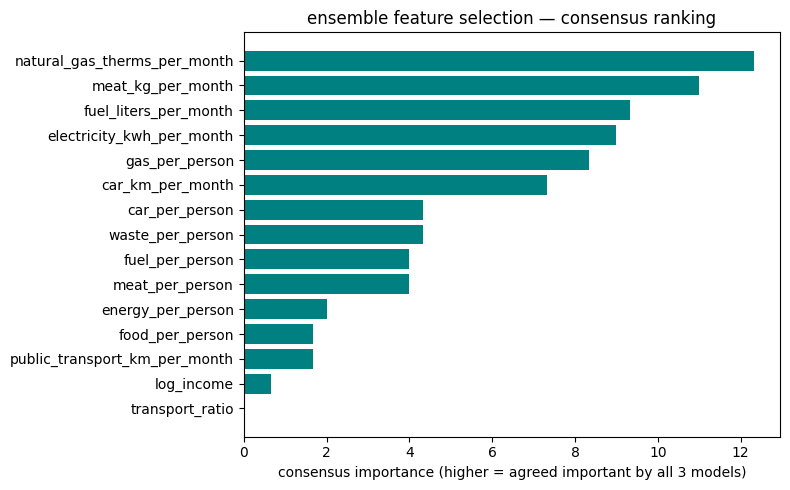

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
consensus_sorted = consensus.sort_values("avg_rank", ascending=False)
ax.barh(consensus_sorted["feature"], consensus_sorted["avg_rank"].max() - consensus_sorted["avg_rank"],
        color="teal")  # longer bar = more important (consensus)
ax.set_xlabel("consensus importance (higher = agreed important by all 3 models)")
ax.set_title("ensemble feature selection — consensus ranking")
plt.tight_layout()
plt.show()

## stacking B — consensus top-7 features

In [9]:
top7 = list(consensus["feature"].head(7))
print("top-7 consensus features:", top7)

X7 = df[top7]
X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y, test_size=0.2, random_state=42, stratify=y
)

lr, rf, xgb = make_base_learners()
stack_top7 = StackingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=cv, n_jobs=-1
)
stack_top7.fit(X7_train, y7_train)

tr_t7 = accuracy_score(y7_train, stack_top7.predict(X7_train))
te_t7 = accuracy_score(y7_test,  stack_top7.predict(X7_test))
print(f"stacking (top7): test={te_t7:.4f}  train={tr_t7:.4f}  gap={tr_t7 - te_t7:+.4f}")

top-7 consensus features: ['natural_gas_therms_per_month', 'meat_kg_per_month', 'fuel_liters_per_month', 'electricity_kwh_per_month', 'gas_per_person', 'car_km_per_month', 'waste_per_person']
stacking (top7): test=0.9500  train=0.9525  gap=+0.0025


With the consensus top-7 features, stacking jumps to **0.95** and the gap nearly vanishes — removing noise lets the weak models stop hurting the ensemble.

## final comparison

             model  test_accuracy
   Stacking (top7)           0.95
       LR (single)           0.93
Stacking (15 feat)           0.93
      XGB (single)           0.81
       RF (single)           0.76


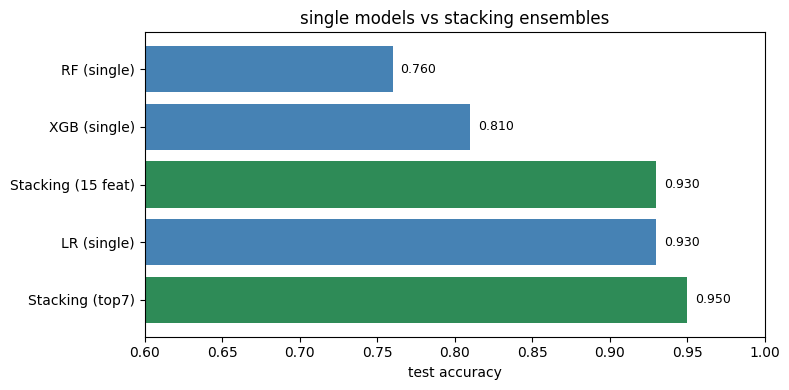

In [10]:
comparison = pd.DataFrame({
    "model": ["LR (single)", "RF (single)", "XGB (single)",
              "Stacking (15 feat)", "Stacking (top7)"],
    "test_accuracy": [single_scores["LR"], single_scores["RF"], single_scores["XGB"],
                      te_full, te_t7]
}).sort_values("test_accuracy", ascending=False)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["seagreen" if "Stacking" in m else "steelblue" for m in comparison["model"]]
ax.barh(comparison["model"], comparison["test_accuracy"], color=colors)
ax.set_xlim(0.6, 1.0)
ax.set_xlabel("test accuracy")
ax.set_title("single models vs stacking ensembles")
for i, v in enumerate(comparison["test_accuracy"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Only the top-7 stacking edges out single LR; the 15-feature version does not.

## confusion matrix — best stacking model

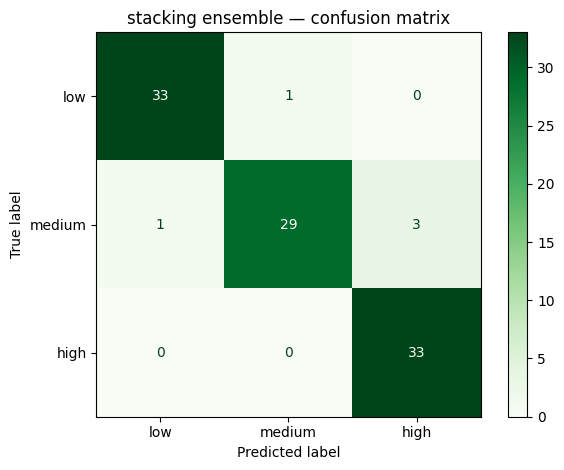

              precision    recall  f1-score   support

         low       0.97      0.97      0.97        34
      medium       0.97      0.88      0.92        33
        high       0.92      1.00      0.96        33

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



In [11]:
best_stack = stack_top7 if te_t7 >= te_full else stack_full
best_X_test, best_y_test = (X7_test, y7_test) if te_t7 >= te_full else (X_test, y_test)

y_pred = best_stack.predict(best_X_test)
cm = confusion_matrix(best_y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["low", "medium", "high"]).plot(cmap="Greens")
plt.title("stacking ensemble — confusion matrix")
plt.tight_layout()
plt.show()

print(classification_report(best_y_test, y_pred, target_names=["low", "medium", "high"]))